# Tuned Model Evaluation

This notebook is for evaluating model runs after training or hyperparameter tuning has already finished. It does not retrain models. Instead, it reads the files produced by the training pipeline, especially `run_info.json`, `model.joblib`, `classification_report_*.csv`, `tuning_cv_results.csv`, and saved PNG images.

The main comparison metric is `test_macro_f2`. F2 weights recall more strongly than precision, which is useful when missing delayed-flight classes is more costly than producing extra false positives. Older runs that were created before F2 was added may show `NaN` for F2 metrics; rerun those models to populate F2 values.

The setup cell below imports plotting and table libraries, configures display options, defines where run folders are searched, and sets `PRIMARY_METRIC = "test_macro_f2"` so all ranking uses the same metric. Update `OUTPUT_ROOTS` if your run folders are stored somewhere else.


In [14]:
from pathlib import Path
import json

from IPython.display import Image, display
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 180)

OUTPUT_ROOTS = [
    Path("outputs/training_notebook_tuned"),
    Path("outputs/training_notebook"),
]
PRIMARY_METRIC = "test_macro_f2"


## Load Runs

This section discovers all persisted runs and converts their JSON metadata into a single table. The expected folder structure is `outputs/.../runs/<run_id>/run_info.json`.

The code cell defines three helper functions. `find_run_info_files()` searches every configured output root for run metadata files. `load_run_info()` reads one JSON file and adds internal path fields so later cells can find the artifacts for that run. `flatten_run()` extracts the nested JSON fields into one flat row with model name, tuning settings, split sizes, feature count, and validation/test metrics.

The output table `runs_df` has one row per run. Use this table to check that the notebook found the expected number of runs and that key fields such as `model_name`, `tuned`, `scoring`, `test_macro_f2`, and `run_dir` look correct.


In [15]:
def find_run_info_files(output_roots):
    run_info_files = []
    for output_root in output_roots:
        run_info_files.extend(sorted((output_root / "runs").glob("*/run_info.json")))
    return run_info_files

def load_run_info(path):
    with path.open(encoding="utf-8") as file:
        run_info = json.load(file)
    run_info["_run_dir"] = str(path.parent)
    run_info["_run_info_path"] = str(path)
    return run_info

def flatten_run(run_info):
    row = {
        "run_id": run_info.get("run_id"),
        "created_at_utc": run_info.get("created_at_utc"),
        "run_dir": run_info.get("_run_dir"),
        "model_name": run_info.get("model", {}).get("name"),
        "model_class": run_info.get("model", {}).get("class_name"),
        "tuned": run_info.get("tuning", {}).get("enabled", False),
        "scoring": run_info.get("tuning", {}).get("scoring"),
        "n_iter": run_info.get("tuning", {}).get("n_iter"),
        "cv_splits": run_info.get("tuning", {}).get("cv_splits"),
        "best_cv_score": run_info.get("tuning", {}).get("best_score"),
        "train_rows": run_info.get("splits", {}).get("train_rows"),
        "validation_rows": run_info.get("splits", {}).get("validation_rows"),
        "test_rows": run_info.get("splits", {}).get("test_rows"),
        "feature_count": run_info.get("features", {}).get("count"),
    }
    for split, metrics in run_info.get("metrics", {}).items():
        if isinstance(metrics, dict) and split in {"validation", "test"}:
            prefix = "val" if split == "validation" else "test"
            for metric_name, value in metrics.items():
                row[f"{prefix}_{metric_name}"] = value
    return row

run_info_files = find_run_info_files(OUTPUT_ROOTS)
runs = [load_run_info(path) for path in run_info_files]
runs_df = pd.DataFrame([flatten_run(run_info) for run_info in runs])

if runs_df.empty:
    raise FileNotFoundError("No run_info.json files found. Check OUTPUT_ROOTS or run training first.")

runs_df["created_at_utc"] = pd.to_datetime(runs_df["created_at_utc"], errors="coerce")
runs_df = runs_df.sort_values(PRIMARY_METRIC, ascending=False, na_position="last").reset_index(drop=True)
print(f"Loaded {len(runs_df)} runs")
runs_df


Loaded 10 runs


,run_id,created_at_utc,run_dir,model_name,model_class,tuned,scoring,n_iter,cv_splits,best_cv_score,train_rows,validation_rows,test_rows,feature_count,val_accuracy,val_balanced_accuracy,val_macro_f1,val_macro_f2,val_weighted_f1,test_accuracy,test_balanced_accuracy,test_macro_f1,test_macro_f2,test_weighted_f1
0,20260514T160213Z_xgboost,2026-05-14 16:02:13.573629+00:00,outputs/training_notebook_tuned/runs/20260514T160213Z_xgboost,xgboost,ClassWeightTunedClassifier,True,fbeta_macro_beta_2,2.0,3.0,0.458953,192361,41220,41221,134,0.730786,0.467747,0.463711,0.464077,0.747490,0.747143,0.478345,0.467547,0.471688,0.763746
1,20260514T160142Z_hist_gradient_boosting,2026-05-14 16:01:43.229737+00:00,outputs/training_notebook_tuned/runs/20260514T160142Z_hist_gradient_boosting,hist_gradient_boosting,ClassWeightTunedClassifier,True,fbeta_macro_beta_2,2.0,3.0,0.452636,192361,41220,41221,134,0.771810,0.456430,0.465542,0.459685,0.770551,0.787366,0.467918,0.471107,0.468611,0.786993
2,20260514T160006Z_random_forest,2026-05-14 16:00:06.818386+00:00,outputs/training_notebook_tuned/runs/20260514T160006Z_random_forest,random_forest,ClassWeightTunedClassifier,True,fbeta_macro_beta_2,2.0,3.0,0.377336,192361,41220,41221,134,0.527365,0.423243,0.393033,0.387092,0.590383,0.535552,0.429451,0.390343,0.388451,0.602925
3,20260514T155936Z_logistic_regression_pipeline,2026-05-14 15:59:36.825816+00:00,outputs/training_notebook_tuned/runs/20260514T155936Z_logistic_regression_pipeline,logistic_regression_pipeline,ClassWeightTunedClassifier,True,fbeta_macro_beta_2,2.0,3.0,0.378847,192361,41220,41221,134,0.703760,0.391075,0.383730,0.387550,0.712878,0.715097,0.379668,0.370987,0.375365,0.725424
4,20260514T152745Z_logistic_regression,2026-05-14 15:27:45.797820+00:00,outputs/training_notebook_tuned/runs/20260514T152745Z_logistic_regression,logistic_regression,ClassWeightTunedClassifier,True,fbeta_macro_beta_2,10.0,3.0,0.257116,1923612,412203,412203,134,0.739623,0.259372,0.250257,0.255309,0.696831,0.747581,0.261525,0.253023,0.257850,0.709416
5,20260514T151821Z_dummy,2026-05-14 15:18:21.772609+00:00,outputs/training_notebook_tuned/runs/20260514T151821Z_dummy,dummy,ClassWeightTunedClassifier,True,fbeta_macro_beta_2,10.0,3.0,0.239444,1923612,412203,412203,134,0.793961,0.250000,0.221287,0.237665,0.702773,0.804567,0.250000,0.222925,0.238417,0.717433
6,20260514T150248Z_dummy,2026-05-14 15:02:48.984340+00:00,outputs/training_notebook_tuned/runs/20260514T150248Z_dummy,dummy,ClassWeightTunedClassifier,True,fbeta_macro_beta_2,10.0,3.0,0.239444,1923612,412203,412203,134,0.793961,0.250000,0.221287,0.237665,0.702773,0.804567,0.250000,0.222925,0.238417,0.717433
7,20260514T112559Z_xgboost,2026-05-14 11:26:02.627517+00:00,outputs/training_notebook/runs/20260514T112559Z_xgboost,xgboost,XGBClassifier,False,None,NaN,NaN,NaN,9618061,2061013,2061014,133,0.804531,0.469842,0.506924,NaN,0.789444,0.815301,0.481074,0.513903,NaN,0.802056
8,20260514T114303Z_random_forest,2026-05-14 11:43:38.687133+00:00,outputs/training_notebook/runs/20260514T114303Z_random_forest,random_forest,RandomForestClassifier,False,None,NaN,NaN,NaN,9618061,2061013,2061014,133,0.616508,0.495689,0.454707,NaN,0.667348,0.617639,0.501942,0.454140,NaN,0.672702
9,20260514T115917Z_logistic_regression,2026-05-14 11:59:20.221958+00:00,outputs/training_notebook/runs/20260514T115917Z_logistic_regression,logistic_regression,LogisticRegression,False,None,NaN,NaN,NaN,9618061,2061013,2061014,133,0.550473,0.354264,0.276503,NaN,0.616988,0.550112,0.356852,0.277197,NaN,0.621205


## Leaderboard

This section creates model comparison tables. Runs are ranked by `test_macro_f2`, because F2 weights recall more than precision. Higher values are better.

The first code cell builds `leaderboard`, which keeps the most important metadata and metrics for every run. This is useful when you want to compare repeated runs of the same model, inspect whether a run was tuned, or jump to the folder where its artifacts were saved.

The second code cell builds `best_by_model`, which keeps only the best run for each `model_name`. This avoids one model dominating the table just because it was run many times. Use this table for model-family comparisons such as tuned logistic regression vs random forest vs XGBoost.

Important interpretation note: compare runs only when they used comparable data splits and sample fractions. The row counts help you spot unfair comparisons, for example a tuned run on a smaller sample versus a full-data untuned run.


In [17]:
metric_columns = [
    "val_macro_f2", "test_macro_f2",
    "val_macro_f1", "test_macro_f1",
    "val_balanced_accuracy", "test_balanced_accuracy",
    "val_accuracy", "test_accuracy",
]
available_metric_columns = [column for column in metric_columns if column in runs_df.columns]
leaderboard_columns = [
    "model_name", "run_id", "tuned", "scoring",
    "best_cv_score", "feature_count",
] + available_metric_columns + ["run_dir"]
leaderboard = runs_df[leaderboard_columns].sort_values(PRIMARY_METRIC, ascending=False, na_position="last")
leaderboard


,model_name,run_id,tuned,scoring,best_cv_score,feature_count,val_macro_f2,test_macro_f2,val_macro_f1,test_macro_f1,val_balanced_accuracy,test_balanced_accuracy,val_accuracy,test_accuracy,run_dir
0,xgboost,20260514T160213Z_xgboost,True,fbeta_macro_beta_2,0.458953,134,0.464077,0.471688,0.463711,0.467547,0.467747,0.478345,0.730786,0.747143,outputs/training_notebook_tuned/runs/20260514T160213Z_xgboost
1,hist_gradient_boosting,20260514T160142Z_hist_gradient_boosting,True,fbeta_macro_beta_2,0.452636,134,0.459685,0.468611,0.465542,0.471107,0.456430,0.467918,0.771810,0.787366,outputs/training_notebook_tuned/runs/20260514T160142Z_hist_gradient_boosting
2,random_forest,20260514T160006Z_random_forest,True,fbeta_macro_beta_2,0.377336,134,0.387092,0.388451,0.393033,0.390343,0.423243,0.429451,0.527365,0.535552,outputs/training_notebook_tuned/runs/20260514T160006Z_random_forest
3,logistic_regression_pipeline,20260514T155936Z_logistic_regression_pipeline,True,fbeta_macro_beta_2,0.378847,134,0.387550,0.375365,0.383730,0.370987,0.391075,0.379668,0.703760,0.715097,outputs/training_notebook_tuned/runs/20260514T155936Z_logistic_regression_pipeline
4,logistic_regression,20260514T152745Z_logistic_regression,True,fbeta_macro_beta_2,0.257116,134,0.255309,0.257850,0.250257,0.253023,0.259372,0.261525,0.739623,0.747581,outputs/training_notebook_tuned/runs/20260514T152745Z_logistic_regression
5,dummy,20260514T151821Z_dummy,True,fbeta_macro_beta_2,0.239444,134,0.237665,0.238417,0.221287,0.222925,0.250000,0.250000,0.793961,0.804567,outputs/training_notebook_tuned/runs/20260514T151821Z_dummy
6,dummy,20260514T150248Z_dummy,True,fbeta_macro_beta_2,0.239444,134,0.237665,0.238417,0.221287,0.222925,0.250000,0.250000,0.793961,0.804567,outputs/training_notebook_tuned/runs/20260514T150248Z_dummy
7,xgboost,20260514T112559Z_xgboost,False,None,NaN,133,NaN,NaN,0.506924,0.513903,0.469842,0.481074,0.804531,0.815301,outputs/training_notebook/runs/20260514T112559Z_xgboost
8,random_forest,20260514T114303Z_random_forest,False,None,NaN,133,NaN,NaN,0.454707,0.454140,0.495689,0.501942,0.616508,0.617639,outputs/training_notebook/runs/20260514T114303Z_random_forest
9,logistic_regression,20260514T115917Z_logistic_regression,False,None,NaN,133,NaN,NaN,0.276503,0.277197,0.354264,0.356852,0.550473,0.550112,outputs/training_notebook/runs/20260514T115917Z_logistic_regression


In [18]:
best_by_model = (
    runs_df.sort_values(PRIMARY_METRIC, ascending=False, na_position="last")
    .groupby("model_name", as_index=False)
    .first()
    .sort_values(PRIMARY_METRIC, ascending=False, na_position="last")
)
best_by_model[["model_name", "run_id", "tuned", "best_cv_score"] + available_metric_columns]


,model_name,run_id,tuned,best_cv_score,val_macro_f2,test_macro_f2,val_macro_f1,test_macro_f1,val_balanced_accuracy,test_balanced_accuracy,val_accuracy,test_accuracy
5,xgboost,20260514T160213Z_xgboost,True,0.458953,0.464077,0.471688,0.463711,0.467547,0.467747,0.478345,0.730786,0.747143
1,hist_gradient_boosting,20260514T160142Z_hist_gradient_boosting,True,0.452636,0.459685,0.468611,0.465542,0.471107,0.456430,0.467918,0.771810,0.787366
4,random_forest,20260514T160006Z_random_forest,True,0.377336,0.387092,0.388451,0.393033,0.390343,0.423243,0.429451,0.527365,0.535552
3,logistic_regression_pipeline,20260514T155936Z_logistic_regression_pipeline,True,0.378847,0.387550,0.375365,0.383730,0.370987,0.391075,0.379668,0.703760,0.715097
2,logistic_regression,20260514T152745Z_logistic_regression,True,0.257116,0.255309,0.257850,0.250257,0.253023,0.259372,0.261525,0.739623,0.747581
0,dummy,20260514T151821Z_dummy,True,0.239444,0.237665,0.238417,0.221287,0.222925,0.250000,0.250000,0.793961,0.804567


## Visualize Metrics

This section turns the leaderboard tables into plots. The first plot is a horizontal bar chart of the best `test_macro_f2` score for each model. It is the quickest way to see which model currently performs best under the chosen F2 objective.

The second plot compares validation macro F2 with test macro F2 for every run. Points near the diagonal indicate similar validation and test behavior. Points far below the diagonal can suggest overfitting to the validation/CV process, while points far above the diagonal may indicate unusually favorable test behavior or noisy estimates.

The third plot is a heatmap of available metrics for the best run of each model. It helps compare tradeoffs between F2, F1, balanced accuracy, and plain accuracy. For imbalanced delay classes, plain accuracy can look high even when minority delay classes are poorly predicted, so use it as supporting context rather than the main selection criterion.


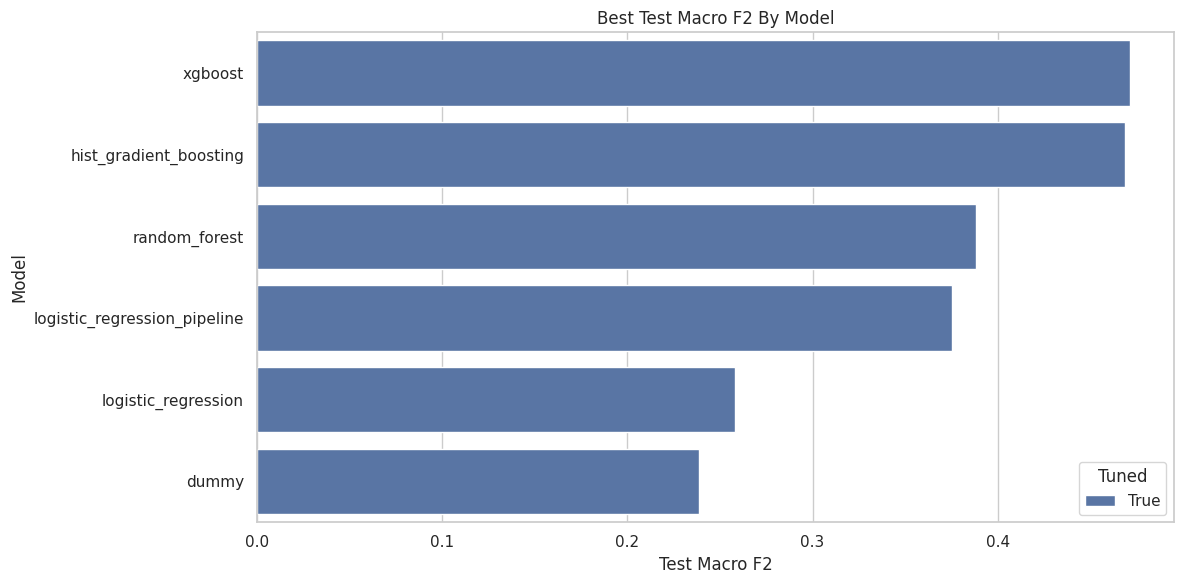

In [19]:
plot_df = best_by_model.dropna(subset=[PRIMARY_METRIC]).copy()
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=plot_df, x=PRIMARY_METRIC, y="model_name", hue="tuned", dodge=False, ax=ax)
ax.set_title("Best Test Macro F2 By Model")
ax.set_xlabel("Test Macro F2")
ax.set_ylabel("Model")
ax.legend(title="Tuned")
plt.tight_layout()


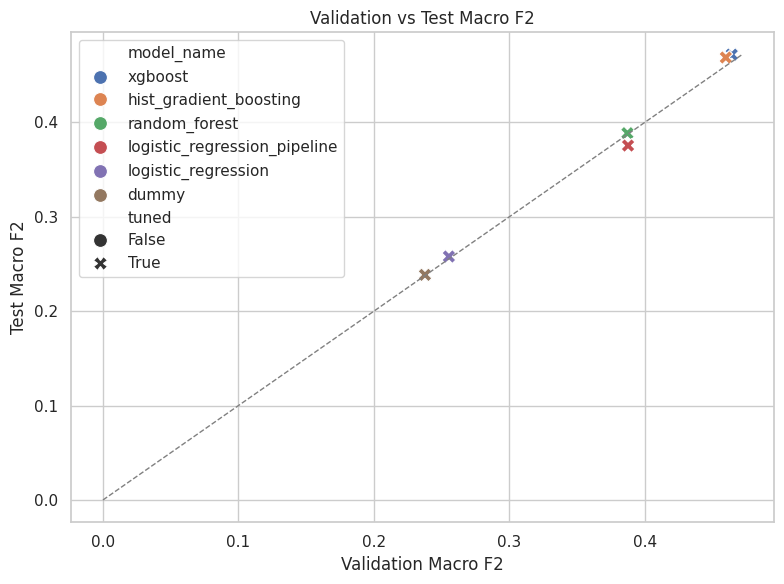

In [20]:
if {"val_macro_f2", "test_macro_f2"}.issubset(runs_df.columns):
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.scatterplot(data=runs_df, x="val_macro_f2", y="test_macro_f2", hue="model_name", style="tuned", s=100, ax=ax)
    max_score = runs_df[["val_macro_f2", "test_macro_f2"]].max().max()
    if pd.notna(max_score):
        ax.plot([0, max_score], [0, max_score], color="gray", linestyle="--", linewidth=1)
    ax.set_title("Validation vs Test Macro F2")
    ax.set_xlabel("Validation Macro F2")
    ax.set_ylabel("Test Macro F2")
    plt.tight_layout()


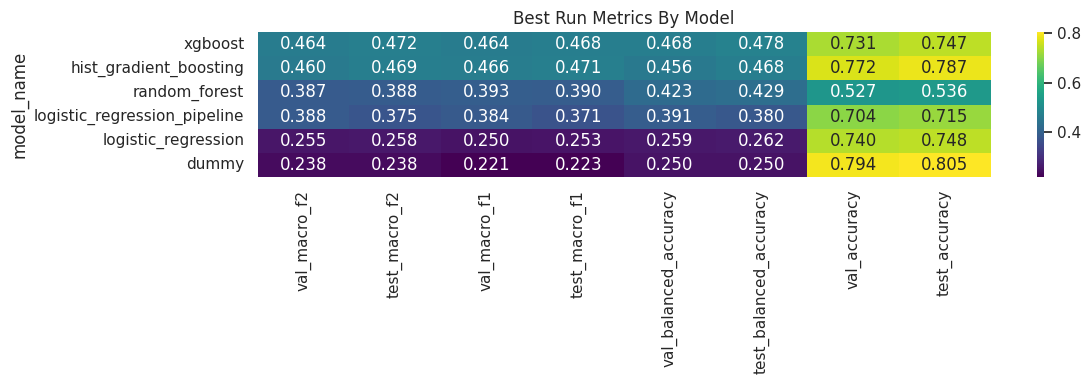

In [21]:
heatmap_df = best_by_model.set_index("model_name")[available_metric_columns].dropna(axis=1, how="all")
fig, ax = plt.subplots(figsize=(12, max(4, 0.5 * len(heatmap_df))))
sns.heatmap(heatmap_df, annot=True, fmt=".3f", cmap="viridis", ax=ax)
ax.set_title("Best Run Metrics By Model")
plt.tight_layout()


## Inspect Best Run

This section drills into the single best run according to `PRIMARY_METRIC`. It is meant for detailed inspection after the leaderboard identifies the strongest candidate.

The first code cell reloads the best run's `run_info.json`, prints the run ID, model name, run folder, and primary metric, then displays the best hyperparameters if the run came from random search. It also displays the test metrics stored in the JSON.

The second code cell loads `classification_report_validation.csv` and `classification_report_test.csv` if they exist. These reports show per-class precision, recall, F1, and support. Check the `medium_delay` and `large_delay` rows carefully because they are usually the harder minority classes.

The third code cell displays any images recorded in `run_info.json`, typically validation/test confusion matrices and feature importances. Confusion matrices show which delay classes are being confused with each other. Feature importance is only available for models that expose importances or coefficients.


In [22]:
best_run_row = runs_df.iloc[0]
best_run_dir = Path(best_run_row["run_dir"])
best_run_info = load_run_info(best_run_dir / "run_info.json")

print(f"Best run: {best_run_info['run_id']}")
print(f"Model: {best_run_info.get('model', {}).get('name')}")
print(f"Run directory: {best_run_dir}")
print(f"{PRIMARY_METRIC}: {best_run_row.get(PRIMARY_METRIC)}")

best_params = best_run_info.get("tuning", {}).get("best_params")
if best_params:
    display(pd.Series(best_params, name="best_params"))

pd.Series(best_run_info.get("metrics", {}).get("test", {}), name="test_metrics")


Best run: 20260514T160213Z_xgboost
Model: xgboost
Run directory: outputs/training_notebook_tuned/runs/20260514T160213Z_xgboost
test_macro_f2: 0.4716880229590284


class_weight_0               0.139990
class_weight_1               0.729624
class_weight_2               1.333709
class_weight_3               1.428600
estimator__learning_rate     0.200000
estimator__max_depth         6.000000
estimator__n_estimators     50.000000
Name: best_params, dtype: float64

accuracy             0.747143
balanced_accuracy    0.478345
macro_f1             0.467547
macro_f2             0.471688
weighted_f1          0.763746
Name: test_metrics, dtype: float64

In [23]:
def load_report(run_dir, filename):
    path = Path(run_dir) / filename
    if path.exists():
        return pd.read_csv(path, index_col=0)
    return None

validation_report = load_report(best_run_dir, "classification_report_validation.csv")
test_report = load_report(best_run_dir, "classification_report_test.csv")

if validation_report is not None:
    print("Validation classification report")
    display(validation_report)
if test_report is not None:
    print("Test classification report")
    display(test_report)


Validation classification report


,precision,recall,f1-score,support
no_delay,0.889440,0.815229,0.850719,32792.000000
small_delay,0.284377,0.407990,0.335148,5657.000000
medium_delay,0.351546,0.424111,0.384434,2306.000000
large_delay,0.390977,0.223656,0.284542,465.000000
accuracy,0.730786,0.730786,0.730786,0.730786
macro avg,0.479085,0.467747,0.463711,41220.000000
weighted avg,0.770686,0.730786,0.747490,41220.000000


Test classification report


,precision,recall,f1-score,support
no_delay,0.900329,0.828006,0.862654,33350.000000
small_delay,0.283112,0.396281,0.330271,5216.000000
medium_delay,0.339838,0.462878,0.391929,2182.000000
large_delay,0.386282,0.226216,0.285333,473.000000
accuracy,0.747143,0.747143,0.747143,0.747143
macro avg,0.477390,0.478345,0.467547,41221.000000
weighted avg,0.786661,0.747143,0.763746,41221.000000


validation_confusion_matrix outputs/training_notebook_tuned/runs/20260514T152745Z_logistic_regression/images/validation_confusion_matrix.png


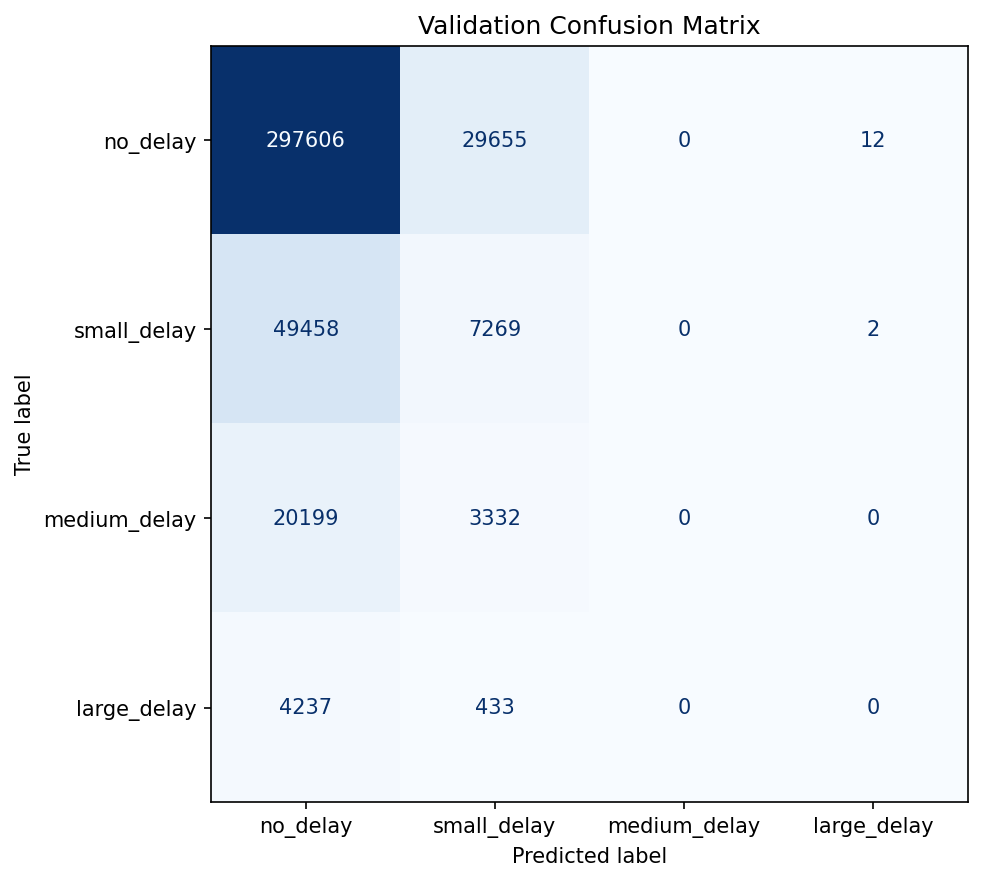

test_confusion_matrix outputs/training_notebook_tuned/runs/20260514T152745Z_logistic_regression/images/test_confusion_matrix.png


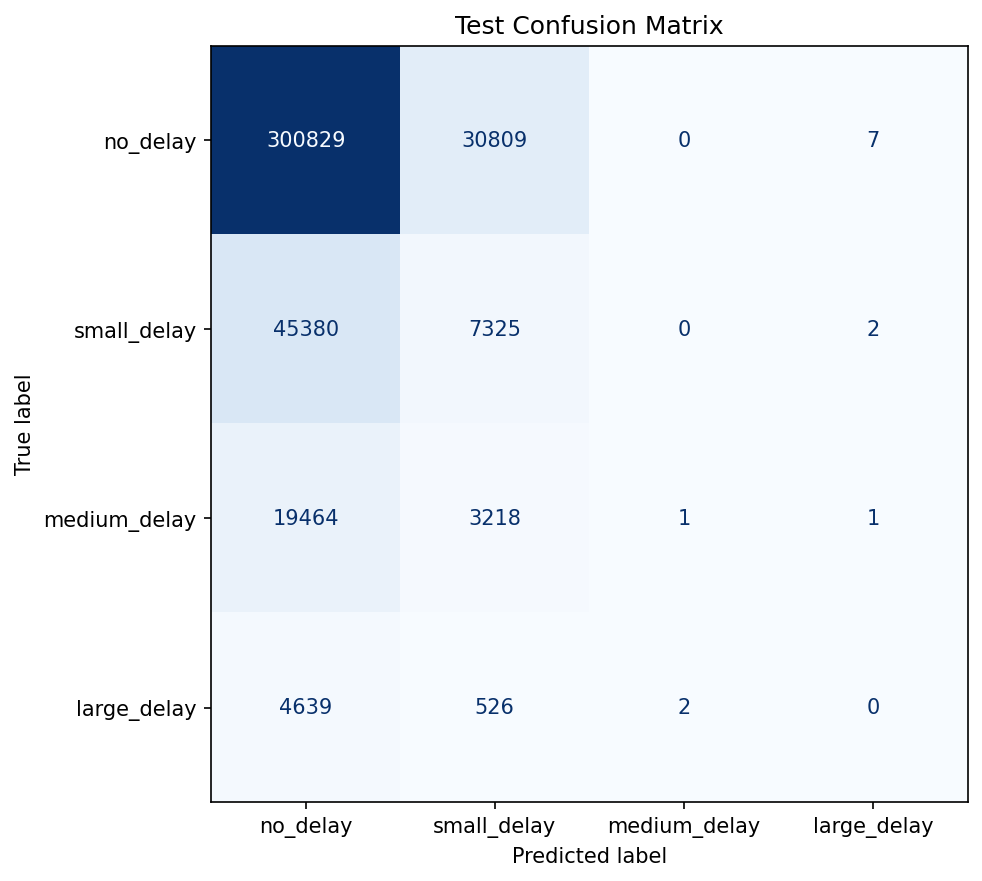

In [10]:
def display_saved_images(run_info):
    run_dir = Path(run_info["_run_dir"])
    images = run_info.get("artifacts", {}).get("images", {})
    if not images:
        print("No saved images recorded for this run.")
        return
    for label, relative_path in images.items():
        image_path = run_dir / relative_path
        print(label, image_path)
        if image_path.exists():
            display(Image(filename=str(image_path)))
        else:
            print(f"Missing image: {image_path}")

display_saved_images(best_run_info)


## Random Search Diagnostics

This section is only active for tuned runs that saved `tuning_cv_results.csv`. It helps explain why random search picked a particular hyperparameter configuration.

The first code cell loads the CV results for the best run and displays the top candidates by `rank_test_score`. The `mean_test_score` column is the cross-validation macro F2 score, because tuning now optimizes F2 with `beta=2`. Parameter columns start with `param_`, including the sampled class-weight values.

The second code cell makes two diagnostic plots. The bar chart shows the top random-search candidates by mean CV F2. The scatter plot shows sampled class weights versus CV F2, which helps reveal whether increasing the weight for a delay class improved or hurt the objective. These plots are exploratory; use them to guide the next search space, not as final proof.


In [11]:
def load_cv_results(run_dir):
    path = Path(run_dir) / "tuning_cv_results.csv"
    if not path.exists():
        return None
    return pd.read_csv(path)

cv_results = load_cv_results(best_run_dir)
if cv_results is None:
    print("No tuning_cv_results.csv found for the best run.")
else:
    cv_display_columns = [column for column in cv_results.columns if column.startswith("param_") or column in {"mean_test_score", "std_test_score", "rank_test_score"}]
    display(cv_results.sort_values("rank_test_score")[cv_display_columns].head(20))


,param_class_weight_0,param_class_weight_1,param_class_weight_2,param_class_weight_3,param_estimator__C,mean_test_score,std_test_score,rank_test_score
0,0.249816,0.975357,1.731994,2.795975,1.00,0.257116,0.003037,1
8,0.221846,0.548836,1.684233,2.320457,1.00,0.246372,0.001940,2
7,0.280200,0.506632,1.942202,2.689865,0.10,0.245568,0.001243,3
9,0.343999,0.916597,1.173365,2.173182,0.10,0.244883,0.002980,4
6,0.305694,0.796207,1.046450,2.822635,0.01,0.244449,0.002924,5
4,0.272778,0.645615,1.611853,1.418482,10.00,0.244197,0.001840,6
2,0.383229,0.510292,1.969910,3.497328,0.10,0.242806,0.001159,7
1,0.278333,0.549987,1.459249,2.001126,10.00,0.242737,0.001055,8
5,0.489502,0.616386,1.090606,2.855158,10.00,0.240033,0.001125,9
3,0.100312,0.996106,1.617482,2.834959,0.01,0.105061,0.003543,10


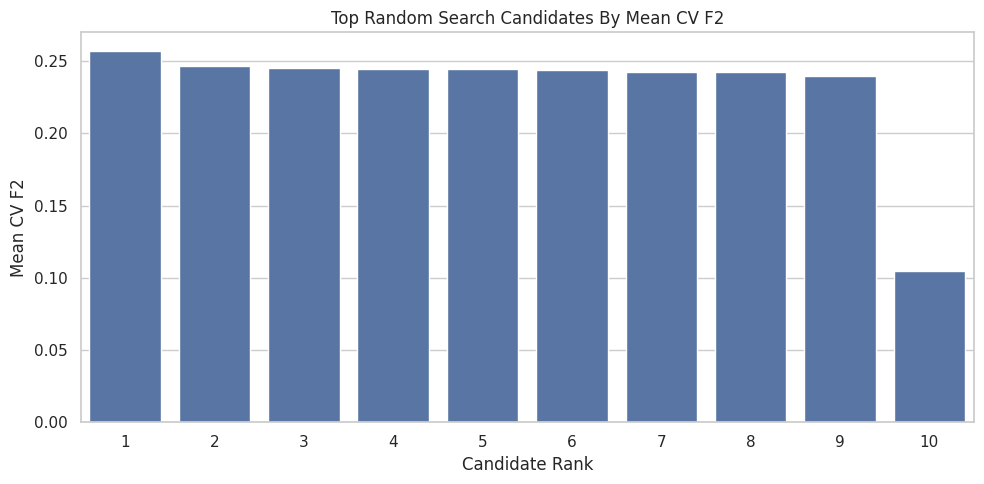

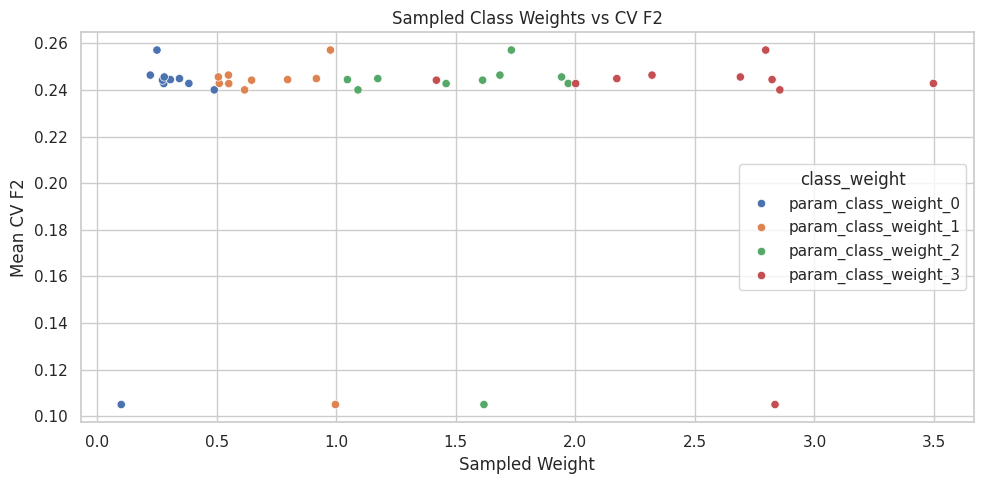

In [12]:
if cv_results is not None and "mean_test_score" in cv_results.columns:
    top_cv = cv_results.sort_values("mean_test_score", ascending=False).head(20).copy()
    top_cv["candidate"] = range(1, len(top_cv) + 1)
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=top_cv, x="candidate", y="mean_test_score", ax=ax)
    ax.set_title("Top Random Search Candidates By Mean CV F2")
    ax.set_xlabel("Candidate Rank")
    ax.set_ylabel("Mean CV F2")
    plt.tight_layout()

    weight_columns = [column for column in cv_results.columns if column.startswith("param_class_weight_")]
    if weight_columns:
        weights_long = cv_results[weight_columns + ["mean_test_score"]].melt(
            id_vars="mean_test_score",
            var_name="class_weight",
            value_name="value",
        )
        fig, ax = plt.subplots(figsize=(10, 5))
        sns.scatterplot(data=weights_long, x="value", y="mean_test_score", hue="class_weight", ax=ax)
        ax.set_title("Sampled Class Weights vs CV F2")
        ax.set_xlabel("Sampled Weight")
        ax.set_ylabel("Mean CV F2")
        plt.tight_layout()


## Export Summaries

This final section writes two CSV files for reporting or sharing outside the notebook. `all_runs_summary.csv` contains one row per discovered run. `best_runs_by_model.csv` contains the best run per model family. Both files are saved under `outputs/tuned_model_evaluation/`.

Rerun this cell whenever new training runs are added and you want the exported CSV summaries to reflect the latest results.


In [13]:
summary_dir = Path("outputs/tuned_model_evaluation")
summary_dir.mkdir(parents=True, exist_ok=True)
runs_df.to_csv(summary_dir / "all_runs_summary.csv", index=False)
best_by_model.to_csv(summary_dir / "best_runs_by_model.csv", index=False)
print(f"Saved summaries to {summary_dir}")


Saved summaries to outputs/tuned_model_evaluation
